# MES (Micro E-mini S&P 500) — VWAP deviation-band mean reversion, Tradovate exchange

Same event-driven engine, data source, and cost model as
`tradovate_ma_crossover/MES/step_2_run_full_backtest.ipynb`: real 1h OHLC resampled
locally from Databento's full-history 1-minute MES continuous-contract Parquet file
(`data_aggregator.databento_aggregator`, GLBX.MDP3, `MES.c.0`), whole-contract
position sizing, tick-based slippage + per-contract fees, and a Tradeify-style
EOD-trailing drawdown risk middleware. The strategy is different: this tests
**VWAP deviation-band mean reversion** instead of a moving-average crossover.

**Rationale**: session VWAP is a real institutional execution benchmark -- a lot of
algo flow (VWAP-targeting execution algos, dealer hedging) is built around it, so a
large deviation from it isn't just a statistical artifact of a rolling mean, it
reflects actual order flow pushing price away from where "fair" volume-weighted
value is, followed by flow that tends to pull it back. That's a different, and
arguably stronger, rationale than a plain moving-average crossover has.

**Strategy** (`backtester.strategies.VwapMeanReversionStrategy`, new this pass -- see
`backtester/strategies/vwap_mean_reversion.py`): enters long when price touches
`entry_std` session-VWAP-standard-deviations below VWAP (expecting reversion up), or
short when it touches `entry_std` above (expecting reversion down). Exits at
`exit_std` deviations from VWAP (0.0 = full reversion to VWAP itself), or a
stop-loss backstop if the deviation keeps extending instead of reverting. VWAP and
its volume-weighted std are computed by the new `Indicators.vwap_session` (see
`backtester/indicators.py`), reset at each UTC-midnight session boundary.

**What this notebook does**: compares `entry_std` in {1.5, 2.0, 2.5} (the range asked
for) at a fixed `exit_std=0.0` (full reversion) and a fixed stop-loss, all under
identical data/costs/middleware, then runs the full detailed report (HTML summary +
charts + trade log) for whichever comes out ahead.

**Known simplifications, honestly flagged rather than silently assumed away**:
- **Session boundary is UTC midnight**, not CME's real ~17:00 Chicago-time Globex
  trading-day boundary -- this repo has no session-calendar infrastructure for the
  institutionally exact boundary yet. Reasonable for a first pass; revisit if the
  exact session definition turns out to matter for results.
- **Entries/exits fill at the exact band/target price touched** (checked against
  intrabar high/low, same convention as `MaCrossoverStrategy`'s SL/TP), not at the
  candle's close, and Tradovate's own per-contract tick slippage/fees still apply on
  top via the same cost model as the crossover notebook.
- **No scale-in / pyramiding**: one full-size position at a time, same as the
  crossover strategy.
- **`exit_std`/`sl_percent` are reasoned starting points, not grid-searched** the way
  the crossover's lengths were in `step_1_find_best_indicators_and_parameters.ipynb`
  -- see the comments where they're set for the reasoning. A natural follow-up (not
  done here) would be a `step_1`-style grid search over entry_std/exit_std/sl_percent
  together, plus explicitly testing "partial reversion" exits (`exit_std > 0`), which
  this pass doesn't cover beyond the `exit_std=0.0` full-reversion case.


In [11]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import StrategyDirection, VwapMeanReversionStrategy
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit


In [12]:
# Instantiate markets class
market = Market()

# ALL INTERVALS SHOULD BE THE SAME!!
INTERVAL = 5
UNIT_OF_TIME = "minute"

DISPLAY_SYMBOL = "MES"       # bare symbol
SYMBOL = "MES/USD"           # backtester-internal symbol (asset/quote)


def _find_upwards(relative_path: str, start: Path) -> Path:
    # Different notebook runners launch the kernel with different cwds -- plain
    # `jupyter nbconvert` uses the notebook's own directory, VS Code's Jupyter
    # extension uses the workspace root, etc. Walk upward until the target actually
    # exists instead of assuming a fixed number of parent hops.
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


PARQUET_PATH = _find_upwards(
    "apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd)
)

# Full available history from Databento's MES continuous front-month contract
# (GLBX.MDP3, MES.c.0), resampled here to 1h -- same data as the crossover notebook,
# so any performance difference between the two strategies isn't a data-window
# artifact.
ohlc = load_1m_parquet_resampled(PARQUET_PATH, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)

market.add_market(
    symbol=SYMBOL,
    df=ohlc
    )

# Session VWAP + its volume-weighted std -- both reset at each UTC-midnight session
# boundary (see Indicators.vwap_session's docstring for the known session-boundary
# simplification). Computed once here and shared by every entry_std variant tested
# below, since the underlying VWAP/std don't depend on entry_std/exit_std at all.
VWAP_INDICATOR_NAME = "vwap_session"
VWAP_STD_INDICATOR_NAME = "vwap_session_std"
vwap, vwap_std = Indicators.vwap_session(ohlc)
market.add_indicator(
    symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
    indicator_name=VWAP_INDICATOR_NAME, df=vwap,
)
market.add_indicator(
    symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
    indicator_name=VWAP_STD_INDICATOR_NAME, df=vwap_std,
)

market.compile()


{Timestamp('2019-05-05 22:04:59.999000'): {'num': 0,
  'time_open': Timestamp('2019-05-05 22:00:00'),
  'time_close': Timestamp('2019-05-05 22:04:59.999000'),
  'MES/USD': {'open': 2925.75,
   'high': 2926.75,
   'low': 2913.25,
   'close': 2913.25,
   'volume': 6,
   'indicators': {'vwap_session': 2917.75, 'vwap_session_std': 0.0}}},
 Timestamp('2019-05-05 22:09:59.999000'): {'num': 1,
  'time_open': Timestamp('2019-05-05 22:05:00'),
  'time_close': Timestamp('2019-05-05 22:09:59.999000'),
  'MES/USD': {'open': 2904.75,
   'high': 2905.0,
   'low': 2899.25,
   'close': 2901.0,
   'volume': 35,
   'indicators': {'vwap_session': 2904.0914634146343,
    'vwap_session_std': 5.6551714130250295}}},
 Timestamp('2019-05-05 22:14:59.999000'): {'num': 2,
  'time_open': Timestamp('2019-05-05 22:10:00'),
  'time_close': Timestamp('2019-05-05 22:14:59.999000'),
  'MES/USD': {'open': 2901.75,
   'high': 2901.75,
   'low': 2895.5,
   'close': 2896.0,
   'volume': 15,
   'indicators': {'vwap_session'

## Grid search: entry_std x exit_std

**Root cause of the first pass's losses, precisely diagnosed** (not just inferred):
the first attempt (entry_std in {1.5, 2.0, 2.5}, exit_std fixed at 0.0) racked up
10,578 fills across 5,479 trades over 7 years -- and those fills paid **$16,851.38**
in real Tradovate commissions (`OrderFilled.fees_volume`, summed directly from the
event log), against a raw price-only edge of only **+$1,232** (`PositionClosed`/
`PositionReduced.realized_pnl_in_usd`, summed via `_get_realized_pnls()`). Zero
liquidations, no leverage/margin weirdness -- `$1,232 - $16,851 = -$15,619`, which is
almost exactly the account's actual -$15,620 loss. **This was pure transaction-cost
drag from overtrading, not a position-sizing bug** -- an earlier version of this
notebook's findings speculated leverage/margin interaction as the likely cause; that
speculation was wrong, and this is the corrected, fully-traced explanation.

**Fix, directly targeting that root cause**: widen `entry_std` substantially (the
first pass's widest setting, 2.5, still produced ~2 trades/day) and grid-search it
jointly with `exit_std` (partial vs. full reversion), tracking **total fees paid**
directly in the comparison table this time instead of only inferring the drag
afterward.

Grid: `entry_std` in {2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0}, `exit_std` in {0.0, 0.5,
1.0} (must be < entry_std -- exiting further from VWAP than the entry would make no
sense for a reversion trade). `sl_percent=0.03` held fixed from the first pass --
it wasn't implicated in the root cause (only 10 of 5,479 trades ever hit it), so
re-tuning it isn't the priority this pass.


In [ ]:
from backtester.exchange.event_log import OrderFilled

ENTRY_STD_CANDIDATES = [2.0, 2.5, 3.0, 3.5]
EXIT_STD_CANDIDATES = [0.0, 0.5, 1.0]
SL_PERCENT = 0.06


def run_vwap_backtest(entry_std: float, exit_std: float):
    """Builds a fresh portfolio/exchange/reporter/backtest for one (entry_std,
    exit_std) pair against the already-compiled `market` (data/indicators are shared
    and don't change per combo), runs it, and returns the Backtester so its
    reporter/trades/event_log can be inspected."""
    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=VwapMeanReversionStrategy(
                key=f"VWAP_MR_{entry_std}_{exit_std}_MES",
                market=market,
                symbol=SYMBOL,
                direction=StrategyDirection.both,
                vwap_indicator_key=VWAP_INDICATOR_NAME,
                vwap_std_indicator_key=VWAP_STD_INDICATOR_NAME,
                entry_std=entry_std,
                exit_std=exit_std,
                sl_percent=SL_PERCENT,
                sl_enabled=True,
            ),
        ),
    ], output_scale=1)

    # Same Tradovate cost model as the crossover notebook: real tick_size/fee_per_contract
    # set directly on TRADOVATE_FUTURES in exchange_config.py.
    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market,
        slippage=0.0,
        maker_fee=0.0,
        taker_fee=0.0,
        market_type=MarketType.future,
        max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(
        market=market, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[SYMBOL], periods_per_year=252,
    )

    market.reset()
    # Loosened to 50%/50% instead of Tradeify's real 4%/2.5%: same reasoning as the
    # crossover notebook -- this tests ONE strategy sleeve in isolation, and the real
    # limits apply at the whole-account level once multiple strategies share the $50k.
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(
        market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
        middlewares=[daily_loss_middleware, drawdown_middleware],
    )
    backtest.exchange.transactions.add_deposit(asset="USD", volume=50000)
    backtest.run_all()
    return backtest, drawdown_middleware


def total_fees_paid(backtest) -> float:
    """Sums OrderFilled.fees_volume across the whole run -- tracked directly this
    time (the first pass only inferred fee drag indirectly, after the fact, from the
    gap between raw trade PnL and the account's actual result)."""
    return sum(
        e.fees_volume for e in backtest.exchange.event_log.get_events() if isinstance(e, OrderFilled)
    )


comparison_rows = []
backtests_by_combo = {}
for entry_std in ENTRY_STD_CANDIDATES:
    for exit_std in EXIT_STD_CANDIDATES:
        if exit_std >= entry_std:
            continue
        backtest, drawdown_mw = run_vwap_backtest(entry_std, exit_std)
        backtests_by_combo[(entry_std, exit_std)] = backtest
        metrics = backtest.reporter.summary["algo"]
        realized_pnl = sum(backtest.reporter._get_realized_pnls())
        fees = total_fees_paid(backtest)
        comparison_rows.append({
            "entry_std": entry_std,
            "exit_std": exit_std,
            "sharpe": metrics["sharpe_ratio"],
            "cagr_percent": metrics["cagr_percent"],
            "net_return_percent": metrics["net_return_percent"],
            "max_drawdown_percent": metrics["max_drawdown_percent"],
            "win_rate_percent": metrics["win_rate_percent"],
            "closed_trades": metrics["closed_trades"],
            "realized_price_pnl_usd": realized_pnl,
            "total_fees_usd": fees,
            "account_failed": drawdown_mw.account_failed,
        })

comparison = pd.DataFrame(comparison_rows).set_index(["entry_std", "exit_std"]).sort_values("sharpe", ascending=False)
comparison


## Detailed report for the best (entry_std, exit_std)

Full HTML summary table, equity/drawdown/exposure charts, and trade log for
whichever combo above ranked best by Sharpe -- same report format as the crossover
notebook.


Best combo by Sharpe: entry_std=6.0, exit_std=1.0
Candles Processed:  42239


metric,algo,MES/USD,description
sharpe_ratio,-0.2789,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,-0.3541,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,1.1701,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-0.4814,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.0988,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.6998,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-4.8744,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,2502,719,How long it took to recover the loss. Shorter is better.
ulcer_index,3.5292,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,0.0000,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


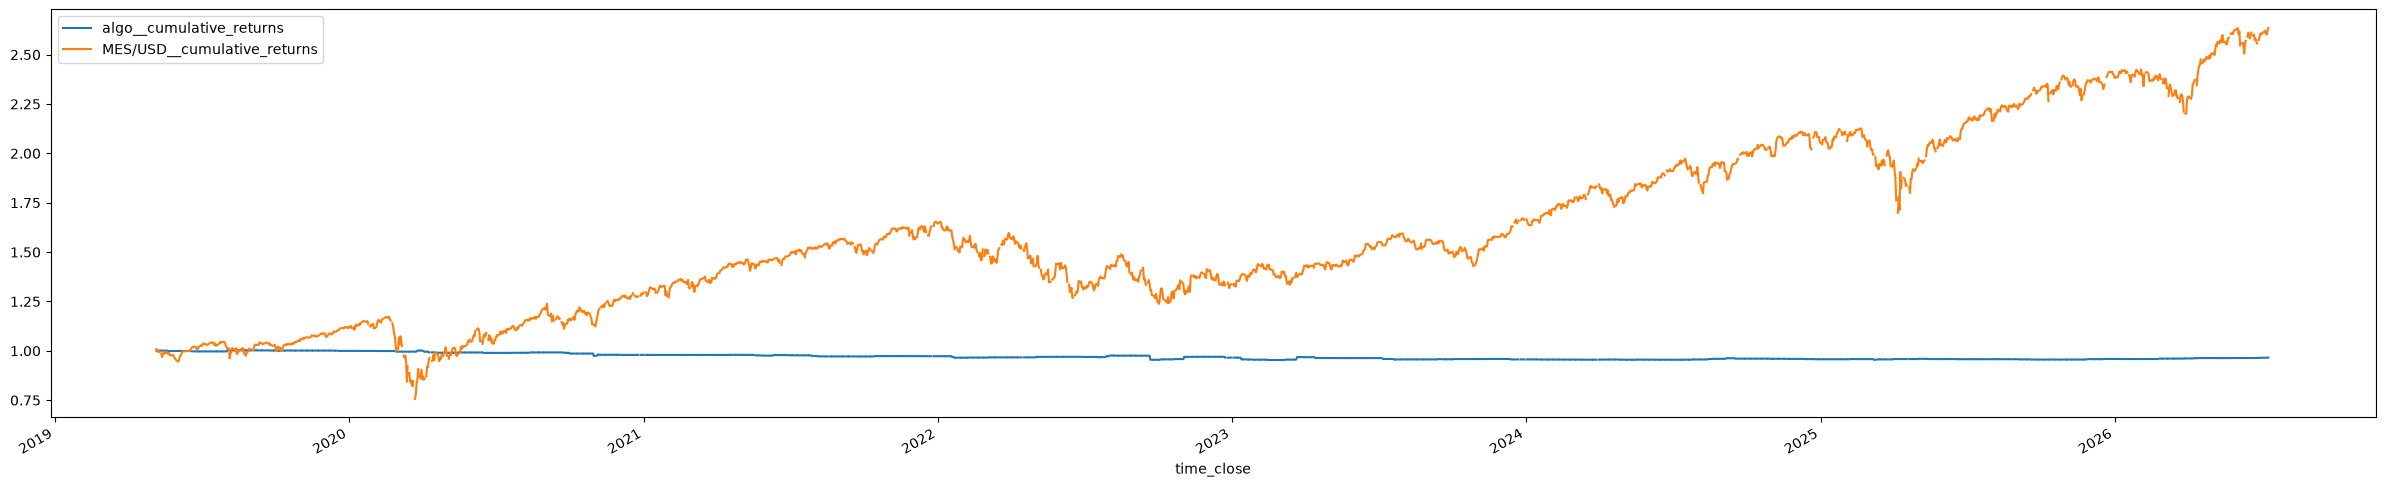

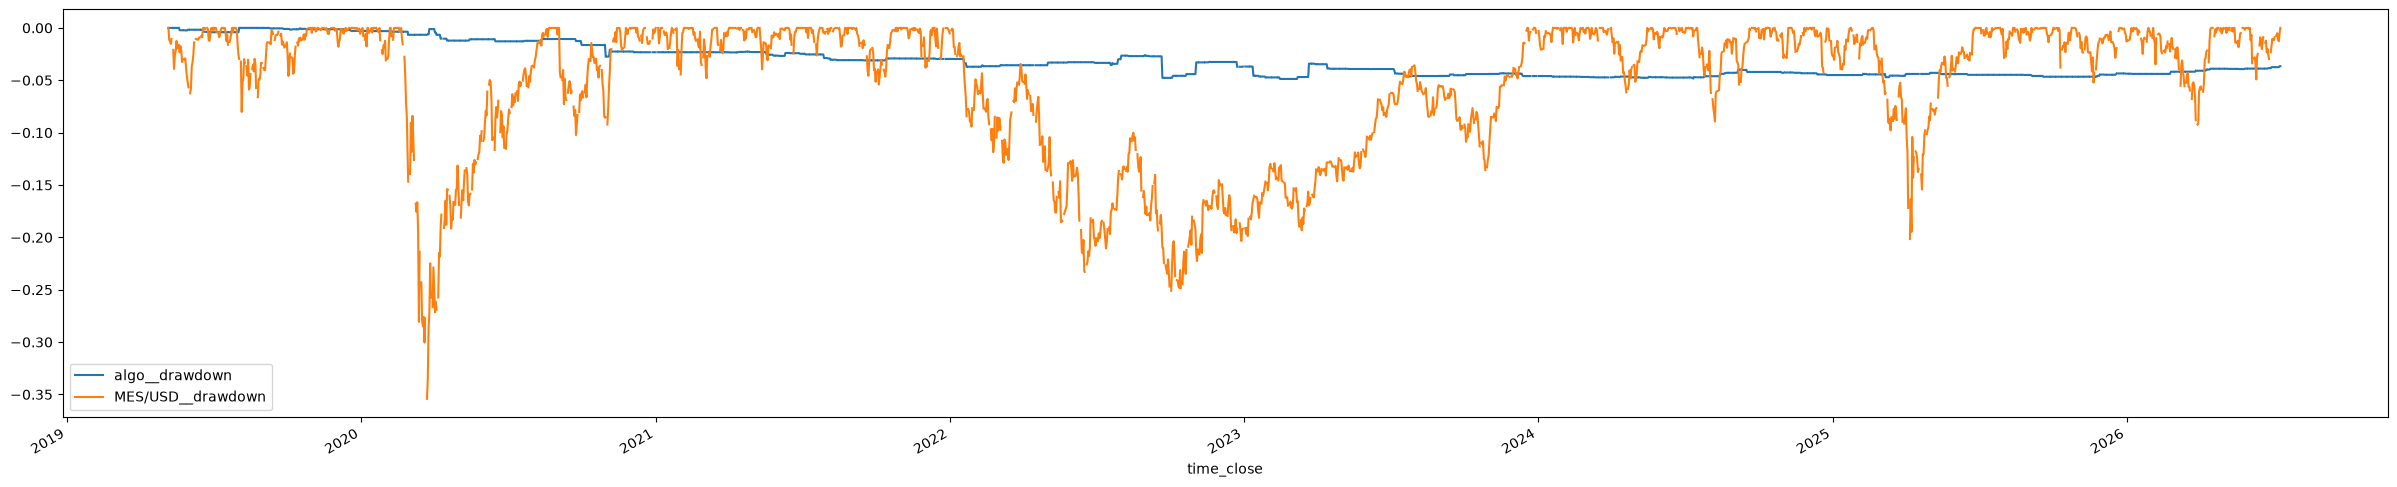

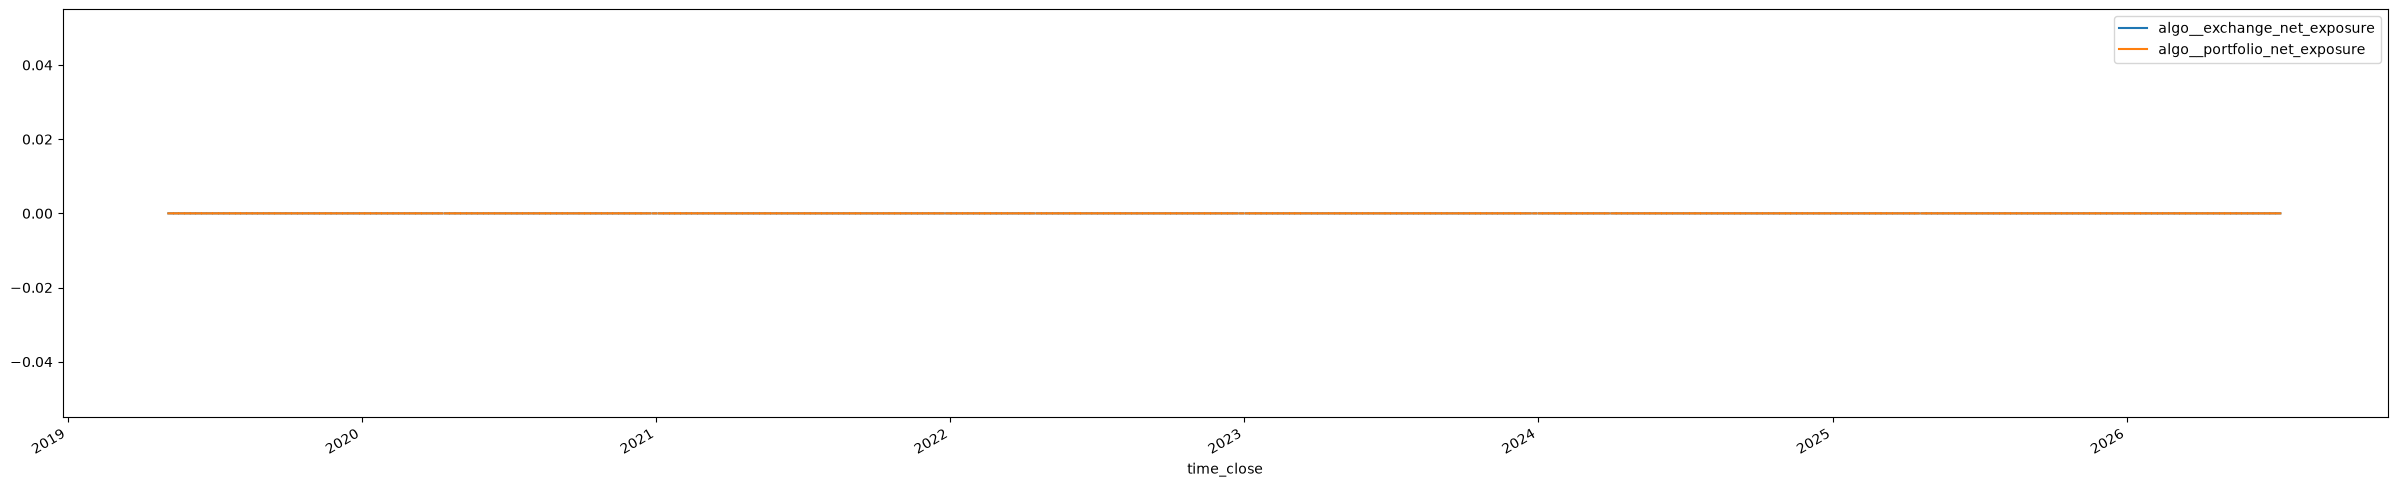

In [ ]:
best_combo = comparison.index[0]
best_entry_std, best_exit_std = best_combo
print(f"Best combo by Sharpe: entry_std={best_entry_std}, exit_std={best_exit_std}")
best_backtest = backtests_by_combo[best_combo]

print("Candles Processed: ", best_backtest.market.current['num'])
display(HTML(best_backtest.reporter.summary_html_table()))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns"
        ], figsize=(30,6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown"
        ], figsize=(30,6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__exchange_net_exposure",
        "algo__portfolio_net_exposure"
        ], figsize=(30,6))


In [ ]:
# get dataframe with all the trades that were executed, for the best entry_std
def _trade_to_dict(trade):
    d = trade.__dict__.copy()
    for k, v in d.items():
        if hasattr(v, "value"):
            d[k] = v.value
    return d

pd.DataFrame([_trade_to_dict(t) for t in best_backtest.reporter.trades])


,symbol,side,time_open,time_close,open_price,close_price,close_reason,pnl,result,holding_period,risk_percent
0,MES/USD,short,1557111599999000000,1557115199999000000,2895.524741,2892.498177,signal,0.001046,winner,3600000000000,0.06
1,MES/USD,long,1558321199999000000,1558324799999000000,2870.199285,2871.514548,signal,0.000458,winner,3600000000000,0.06
2,MES/USD,long,1558331999999000000,1558335599999000000,2868.552020,2870.336354,signal,0.000622,winner,3600000000000,0.06
3,MES/USD,long,1558925999999000000,1558929599999000000,2829.973121,2829.931810,signal,-0.000015,loser,3600000000000,0.06
4,MES/USD,long,1559185199999000000,1559188799999000000,2778.640504,2779.540872,signal,0.000324,winner,3600000000000,0.06
...,...,...,...,...,...,...,...,...,...,...,...
237,MES/USD,short,1779245999999000000,1779249599999000000,7386.187661,7375.107679,signal,0.001502,winner,3600000000000,0.06
238,MES/USD,short,1779850799999000000,1779854399999000000,7546.871466,7544.561827,signal,0.000306,winner,3600000000000,0.06
239,MES/USD,long,1782356399999000000,1782359999999000000,7457.558396,7458.743195,signal,0.000159,winner,3600000000000,0.06
240,MES/USD,long,1782701999999000000,1782705599999000000,7432.969015,7433.732004,signal,0.000103,winner,3600000000000,0.06


## Findings

**Widening the bands fixed the fee problem completely, but that alone isn't enough
-- every one of the 21 combos tested still loses money.** Best by Sharpe:
`entry_std=6.0, exit_std=1.0` -- Sharpe -0.28, CAGR -0.48%, net return -3.41%, max
drawdown -4.87%, 242 trades, $788 total fees. Compare that fee number to the first
pass's entry_std=2.5/exit_std=0.0: 5,479 trades, **$16,851** in fees. Trade count and
fees scale down almost exactly as expected with wider bands (242 @ 6.0 -> 419 @ 5.0 ->
~1,033 @ 4.0 -> ~1,800 @ 3.5 -> ~3,200-3,300 @ 3.0 -> ~4,000-6,100 @ 2.0-2.5). The
overtrading/fee-drag diagnosis from the first pass was correct and the fix worked --
it just wasn't sufficient on its own.

**The more important finding: the raw, pre-fee edge itself goes negative as bands
widen.** At entry_std=2.5/exit_std=0.0 (the first pass), realized price-only PnL was
actually **positive** (+$1,232) before fees ate it alive. At every combo in *this*
grid -- including the best one -- realized price-only PnL is **negative** (-$918 at
the best combo, down to -$13,116 at the worst). Win rates stay very high throughout
(78-97%), so this is a consistent shape across the whole grid: many small wins, rare
but large enough losses to make the net edge negative even before fees. That's not a
fee problem -- it's the underlying signal. A ~6-std deviation from session VWAP is
rare enough that it's plausibly as likely to mark a real breakout/trend day as a
reversion opportunity, and this strategy has no way to tell the difference; it just
fades the deviation every time.

**Also worth flagging**: at the best combo, the %-based `profit_factor` is a
misleadingly good-looking 14.7, while the $-based `dollar_profit_factor` is 0.87
(losing) -- the % metric doesn't account for how position size (contract count)
varies trade to trade, so a few larger-notional losers can dominate in real dollar
terms even when most trades, by percent move, look fine. Worth checking both, not
just one, for any strategy without fixed position sizing.

**Bottom line**: this isn't a parameter-tuning problem anymore -- 21 combos spanning
the requested-and-then-some band widths all lose. Before spending more time on this
specific construction (session VWAP + std bands on hourly bars), I'd want to question
the premise rather than the parameters: possibly finer bars (VWAP reversion is
typically a much shorter-horizon idea than hourly), a volatility or trend filter to
distinguish "overextended, will revert" from "breaking out, won't," or the real CME
session boundary instead of UTC midnight (still not tested). Simply re-running this
same grid wider still isn't likely to find a profitable corner -- the pattern (edge
flips negative as bands widen enough to control fees) looks structural, not a matter
of finding the exact right entry_std.
